<a href="https://colab.research.google.com/github/laraaskovic/Adversarial_Regression_Testing_Engine/blob/main/GRPO_Countdown_RLVR_Hack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRPO Fine-tuning + Activation Analysis
## Teaching Qwen2.5-1.5B to Reason with RL, then looking inside

**What this does:**
1. Generates a countdown puzzle dataset (no downloads needed)
2. Fine-tunes Qwen2.5-1.5B with GRPO — same algorithm as DeepSeek-R1
3. Probes attention activations before vs after RL to show what changed internally

**Runtime:** ~25 mins on T4 GPU

> Before running: **Runtime → Change runtime type → T4 GPU**

In [1]:
# Cell 1: Install
!pip install -q transformers datasets trl accelerate
print('Done')

Done


In [2]:
# Cell 2: Imports and config
import re, random, itertools, torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from IPython.display import clear_output
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Go to Runtime -> Change runtime type -> T4 GPU')

MODEL_NAME  = 'Qwen/Qwen2.5-0.5B-Instruct'   # was 1.5B
MAX_STEPS   = 150
NUM_GEN     = 4
BATCH_SIZE  = 2
MAX_TOKENS  = 120                              # was 180
LR          = 1e-5

SYSTEM_PROMPT = (
    'You are a math puzzle solver.\n'
    'Given some numbers and a target, write an arithmetic expression\n'
    'using those numbers that equals the target.\n'
    'You may use +, -, *, / and each number at most once.\n\n'
    'Think step by step inside <think> tags.\n'
    'Then write ONLY the final expression inside <answer> tags.\n\n'
    'Example:\n'
    'Numbers: 2 3 5  Target: 11\n'
    '<think>\n'
    '2 + 3 = 5, not 11\n'
    '3 * 5 = 15, too big\n'
    '2 + 3 + 5 = 10, close\n'
    '5 * 3 - 2 = 13, no\n'
    '(2 + 3) * 5 = 25, no\n'
    '3 + 5 + 2 = 10, no\n'
    '5 + 3 * 2 = 11, yes!\n'
    '</think>\n'
    '<answer>5 + 3 * 2</answer>'
)
print('Config ready')

Device: cuda
GPU: Tesla T4
Config ready


In [3]:
# Cell 3: Generate countdown puzzles
# We generate our own dataset so there are no downloads,
# no dollar signs, no parsing issues.
# Each puzzle: given 3 small numbers, reach a target using +/-/*
# We only keep puzzles that ARE solvable so the model can always be rewarded.

def find_solution(nums, target):
    '''
    Try all orderings and operator combos to find a solution.
    Returns an expression string if solvable, else None.
    Only uses + - * to keep expressions simple enough for 1.5B.
    '''
    ops = ['+', '-', '*']
    for perm in itertools.permutations(nums):
        for o1 in ops:
            for o2 in ops:
                # Try: a op1 b op2 c
                expr = f'{perm[0]} {o1} {perm[1]} {o2} {perm[2]}'
                try:
                    if abs(eval(expr) - target) < 0.001:
                        return expr
                except:
                    pass
                # Try: (a op1 b) op2 c
                expr = f'({perm[0]} {o1} {perm[1]}) {o2} {perm[2]}'
                try:
                    if abs(eval(expr) - target) < 0.001:
                        return expr
                except:
                    pass
                # Try: a op1 (b op2 c)
                expr = f'{perm[0]} {o1} ({perm[1]} {o2} {perm[2]})'
                try:
                    if abs(eval(expr) - target) < 0.001:
                        return expr
                except:
                    pass
    return None

def generate_puzzles(n=600, seed=42):
    '''
    Generate n solvable countdown puzzles.
    Numbers: 1-9, Target: 10-30 (small enough for 1.5B to handle).
    '''
    random.seed(seed)
    puzzles = []
    attempts = 0
    while len(puzzles) < n and attempts < n * 20:
        attempts += 1
        nums   = [random.randint(1, 9) for _ in range(3)]
        target = random.randint(10, 30)
        sol    = find_solution(nums, target)
        if sol is not None:
            puzzles.append({'numbers': nums, 'target': target, 'solution': sol})
    print(f'Generated {len(puzzles)} solvable puzzles in {attempts} attempts')
    return puzzles

puzzles = generate_puzzles(600)

# Format each puzzle into a chat prompt
def make_prompt(p):
    nums_str = ' '.join(map(str, p['numbers']))
    problem  = f"Numbers: {nums_str}  Target: {p['target']}"
    msgs = [
        {'role': 'system',  'content': SYSTEM_PROMPT},
        {'role': 'user',    'content': problem},
    ]
    return {
        'prompt':   tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True),
        'problem':  problem,
        'numbers':  str(p['numbers']),
        'target':   str(p['target']),
        'solution': p['solution'],
    }

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

dataset = Dataset.from_list([make_prompt(p) for p in puzzles])
print(f'Dataset: {len(dataset)} examples')
print(f'Sample problem: {dataset[0]["problem"]}')
print(f'Sample solution: {dataset[0]["solution"]}')

Generated 600 solvable puzzles in 2543 attempts
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset: 600 examples
Sample problem: Numbers: 2 7 1  Target: 10
Sample solution: 2 + 7 + 1


In [4]:
# Cell 4: Reward function
# The reward is verifiable: just eval() the expression and check it equals target.
# This is RLVR — no LLM judge, no human labels, pure math verification.

def extract_answer(text):
    '''Pull expression from <answer>...</answer> tags.'''
    m = re.search(r'<answer>\s*(.+?)\s*</answer>', text, re.DOTALL)
    return m.group(1).strip() if m else None

def is_valid_expr(expr, numbers, target):
    '''
    Check if expression:
      1. Evaluates to target
      2. Only uses the given numbers (no extra numbers snuck in)
      3. Contains only safe characters
    '''
    if expr is None: return False
    # Safety: only allow digits, operators, spaces, parens
    if not re.match(r'^[\d\s\+\-\*\/\(\)\.]+$', expr): return False
    # Check numbers used match given numbers
    nums_in_expr = sorted([int(x) for x in re.findall(r'\d+', expr)])
    nums_given   = sorted([int(x) for x in numbers.strip('[]').split(',')])
    if nums_in_expr != nums_given: return False
    # Evaluate
    try:
        result = eval(expr)
        return abs(result - float(target)) < 0.01
    except:
        return False

def compute_reward(response, numbers, target):
    '''
    +1.0  correct expression in <answer> tags
    +0.2  used <think> tags (format bonus)
    -1.0  wrong or missing answer
    '''
    expr       = extract_answer(response)
    has_think  = bool(re.search(r'<think>.*?</think>', response, re.DOTALL))
    fmt_bonus  = 0.2 if has_think else 0.0
    if is_valid_expr(expr, numbers, target):
        return 1.0 + fmt_bonus
    return -1.0 + fmt_bonus

# Training log for the dashboard
log = {'steps':[],'rewards':[],'accuracies':[],'think_rates':[],'lengths':[],'samples':[]}
step_counter = [0]

def grpo_reward_fn(prompts, completions, **kwargs):
    numbers = kwargs.get('numbers', ['']*len(completions))
    targets = kwargs.get('target',  ['']*len(completions))
    problems= kwargs.get('problem', ['']*len(completions))
    rewards, correct, think_used, lengths = [], 0, 0, []
    for comp, nums, tgt in zip(completions, numbers, targets):
        r = compute_reward(comp, nums, tgt)
        rewards.append(r)
        if r >= 1.0:        correct    += 1
        if '<think>' in comp: think_used += 1
        lengths.append(len(comp.split()))
    n = len(completions)
    step_counter[0] += 1
    s = step_counter[0]
    log['steps'].append(s)
    log['rewards'].append(round(sum(rewards)/n, 4))
    log['accuracies'].append(round(correct/n, 4))
    log['think_rates'].append(round(think_used/n, 4))
    log['lengths'].append(round(sum(lengths)/n, 1))
    if s % 10 == 0:
        best_i = rewards.index(max(rewards))
        log['samples'].append({
            's': s,
            'p': list(problems)[0] if problems else '',
            'r': completions[best_i],
            'w': round(rewards[best_i], 2)
        })
        log['samples'] = log['samples'][-6:]
    if s % 5 == 0: plot_dashboard()
    return rewards

print('Reward function ready')
# Quick sanity check
r = compute_reward('<think>1+2=3</think><answer>5 + 3 * 2</answer>', '[5, 3, 2]', '11')
print(f'Sanity check reward (should be 1.2): {r}')

Reward function ready
Sanity check reward (should be 1.2): 1.2


In [5]:
# Cell 5: Live dashboard
def smooth(v, w=8):
    return pd.Series(v).rolling(w, min_periods=1).mean().tolist()

def styled(ax, title, ylabel):
    ax.set_facecolor('#1c1f26')
    ax.tick_params(colors='#aaa', labelsize=8)
    ax.set_title(title, color='white', fontsize=10, pad=5)
    ax.set_xlabel('Step', color='#aaa', fontsize=8)
    ax.set_ylabel(ylabel, color='#aaa', fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#2d3139')
    ax.grid(color='#2d3139', linewidth=0.5)

def plot_dashboard():
    if not log['steps']: return
    clear_output(wait=True)
    fig = plt.figure(figsize=(15, 10))
    fig.patch.set_facecolor('#0e1117')
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)
    st  = log['steps']
    ax1 = fig.add_subplot(gs[0,0])
    ax1.plot(st, log['rewards'], color='#00d4aa', alpha=0.25, lw=1)
    ax1.plot(st, smooth(log['rewards']), color='#00d4aa', lw=2.5, label='reward')
    ax1.axhline(0, color='gray', ls='--', alpha=0.4)
    ax1.set_ylim(-1.3, 1.3)
    styled(ax1, 'Mean Reward', 'Reward')
    ax2 = fig.add_subplot(gs[0,1])
    acc = [a*100 for a in log['accuracies']]
    ax2.plot(st, acc, color='#7c6af7', alpha=0.25, lw=1)
    ax2.plot(st, smooth(acc), color='#7c6af7', lw=2.5)
    ax2.set_ylim(0, 105)
    styled(ax2, 'Accuracy (%)', 'Accuracy')
    ax3 = fig.add_subplot(gs[1,0])
    ax3.bar(st, [t*100 for t in log['think_rates']], color='#f7a76c', alpha=0.75, width=0.9)
    ax3.set_ylim(0, 105)
    styled(ax3, 'Think Tag Usage (%)', '% Responses')
    ax4 = fig.add_subplot(gs[1,1])
    ax4.fill_between(st, log['lengths'], alpha=0.25, color='#f76c6c')
    ax4.plot(st, log['lengths'], color='#f76c6c', lw=2)
    styled(ax4, 'Response Length (words)', 'Words')
    ax5 = fig.add_subplot(gs[2,:])
    ax5.set_facecolor('#1c1f26')
    ax5.axis('off')
    s = log['steps'][-1]; rw = log['rewards'][-1]
    ac = log['accuracies'][-1]; th = log['think_rates'][-1]
    status = f'Step {s}/{MAX_STEPS}  |  Reward {rw:+.3f}  |  Accuracy {ac:.1%}  |  Think rate {th:.1%}'
    ax5.text(0.5, 0.97, status, transform=ax5.transAxes,
             color='#00d4aa', fontsize=10, ha='center', va='top', fontfamily='monospace')
    if log['samples']:
        smp  = log['samples'][-1]
        prob = smp['p'][:100]
        resp = smp['r'][:320].replace('$', 'USD')
        ax5.text(0.01, 0.82, f"Step {smp['s']}  reward {smp['w']:+.2f}",
                 transform=ax5.transAxes, color='#888', fontsize=8, va='top')
        ax5.text(0.01, 0.73, f'Q: {prob}',
                 transform=ax5.transAxes, color='#ccc', fontsize=8, va='top')
        ax5.text(0.01, 0.52, resp, transform=ax5.transAxes,
                 color='#00d4aa', fontsize=7.5, va='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#0a0d12', alpha=0.8, pad=0.3))
    fig.suptitle('GRPO Training  |  Qwen2.5-1.5B  |  Countdown Puzzles  |  RLVR',
                 color='white', fontsize=12, y=0.99)
    plt.show()
    print(f'Step {s:4d}/{MAX_STEPS} | Reward {rw:+.3f} | Acc {ac:.1%} | Think {th:.1%}')

print('Dashboard ready')

Dashboard ready


In [6]:
# Cell 6: Load model and show baseline response
print('Loading model (~3GB, ~2 min)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16, device_map='auto'
)
print(f'Loaded: {sum(p.numel() for p in model.parameters())/1e6:.0f}M params')

# Store baseline activations BEFORE training for comparison later
baseline_activations = {}
hooks = []

def make_hook(name):
    def hook(module, input, output):
        # output[0] is the hidden state tensor
        if isinstance(output, tuple):
            baseline_activations[name] = output[0].detach().cpu().float().mean(dim=1)
        else:
            baseline_activations[name] = output.detach().cpu().float().mean(dim=1)
    return hook

# Hook every transformer layer so we can compare before vs after
for i, layer in enumerate(model.model.layers):
    h = layer.register_forward_hook(make_hook(f'layer_{i}'))
    hooks.append(h)

# Run a forward pass to capture baseline activations
test_puzzle = dataset[0]
test_input  = tokenizer(test_puzzle['prompt'], return_tensors='pt').to(device)
with torch.no_grad():
    _ = model(**test_input)

# Remove hooks — we only needed them for the baseline capture
for h in hooks: h.remove()
hooks.clear()

print(f'Baseline activations captured: {len(baseline_activations)} layers')

# Show baseline response (before training)
print('\n=== BASELINE RESPONSE (before GRPO) ===')
with torch.no_grad():
    out = model.generate(**test_input, max_new_tokens=150, do_sample=True,
                         temperature=0.8, pad_token_id=tokenizer.pad_token_id)
baseline_response = tokenizer.decode(out[0][test_input['input_ids'].shape[1]:], skip_special_tokens=True)
baseline_reward   = compute_reward(baseline_response, test_puzzle['numbers'], test_puzzle['target'])
print(f'Problem:  {test_puzzle["problem"]}')
print(f'Response: {baseline_response}')
print(f'Reward:   {baseline_reward:+.2f}')

Loading model (~3GB, ~2 min)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: 494M params
Baseline activations captured: 24 layers

=== BASELINE RESPONSE (before GRPO) ===
Problem:  Numbers: 2 7 1  Target: 10
Response: 2 * (7 - 1) = 9, no
(2 * 7) - 1 = 13, too small
2 + 7 + 1 = 10, exact
2 * 7 + 1 = 14, also wrong
10 - 2 - 7 = 1, wrong
(10 - 2) * 7 = 68, too large
2 * (10 - 7) = 14, same as above
10 - 2 + 7 = 15, correct
10 - 2 - 7 = 1, wrong again

The only correct solution is 2 * (1
Reward:   -1.00


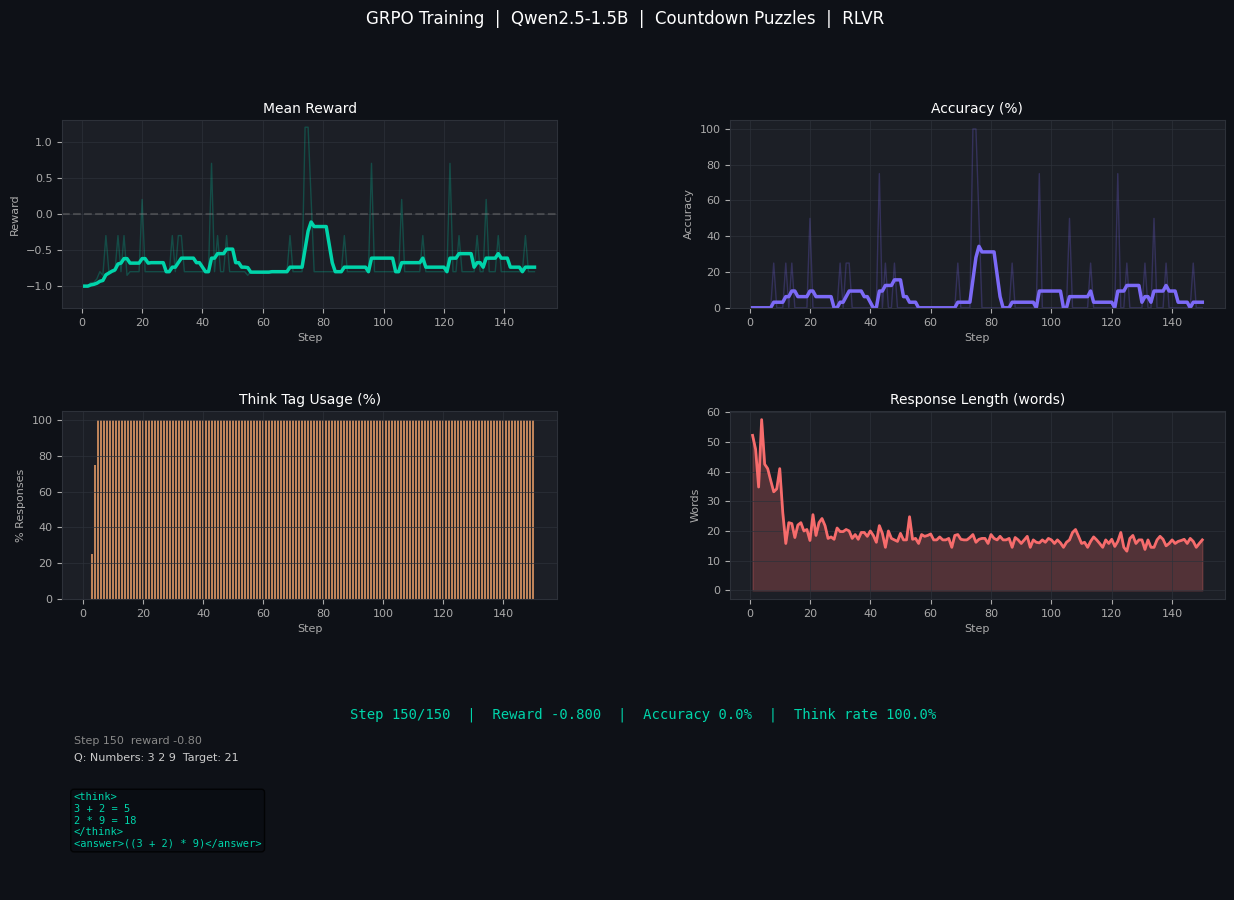

Step  150/150 | Reward -0.800 | Acc 0.0% | Think 100.0%


Step,Training Loss
1,0.000000
2,0.000000
3,-0.188456
4,0.197915
5,0.461665
6,0.000000
7,0.344726
8,0.196731
9,0.000000
10,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


In [7]:
# Cell 7: GRPO Training
grpo_config = GRPOConfig(
    max_steps                   = MAX_STEPS,
    per_device_train_batch_size = 2,
    num_generations             = 4,
    max_completion_length       = MAX_TOKENS,
    learning_rate               = LR,
    temperature                 = 0.9,
    output_dir                  = './grpo_out',
    logging_steps               = 1,
    save_steps                  = 999,
    push_to_hub                 = False,
    report_to                   = 'none',
    bf16                        = (device == 'cuda'),
    gradient_accumulation_steps = 2,
    gradient_checkpointing      = True,   # cuts memory ~40%
)

trainer = GRPOTrainer(
    model            = model,
    args             = grpo_config,
    train_dataset    = dataset,
    reward_funcs     = grpo_reward_fn,
    processing_class = tokenizer,
)

print(f'Starting GRPO: {MAX_STEPS} steps x 4 generations')
print('Dashboard updates every 5 steps...\n')
trainer.train()
print('\nTraining complete!')

Capturing post-training activations...


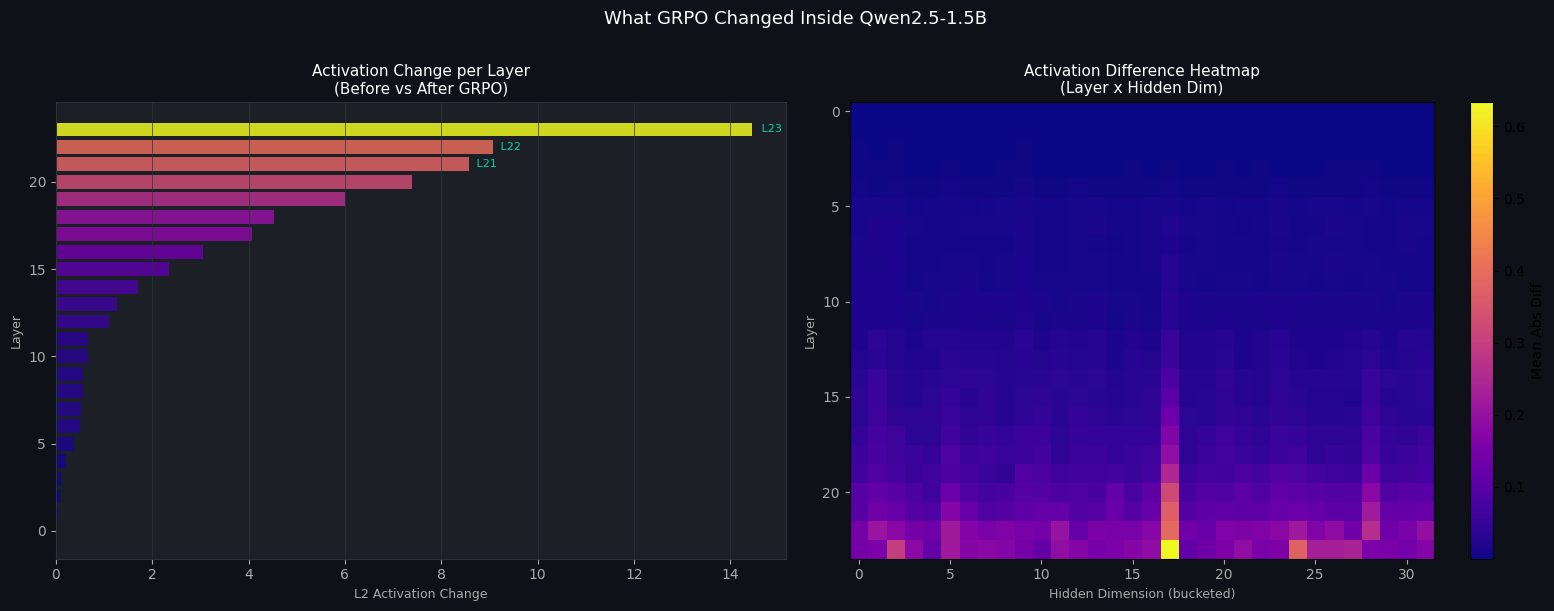

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Most changed layers: [23, 22, 21]
(Later layers tend to change more — they handle reasoning/output formatting)
Problem: Numbers: 2 3 5  Target: 10
Response: <th/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T
Reward: -1.00

Problem: Numbers: 1 2 3  Target: 6
Response: <th/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T
Reward: -1.00

Problem: Numbers: 2 4 1  Target: 9
Response: <th/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T/T

In [10]:
# Cell 8: Activation analysis — what did GRPO change inside the model?
# We compare the mean hidden state magnitude at each layer
# before vs after training on the same input.
# Layers that changed a lot = layers most affected by RL training.

print('Capturing post-training activations...')
post_activations = {}
hooks = []

def make_post_hook(name):
    def hook(module, input, output):
        if isinstance(output, tuple):
            post_activations[name] = output[0].detach().cpu().float().mean(dim=1)
        else:
            post_activations[name] = output.detach().cpu().float().mean(dim=1)
    return hook

for i, layer in enumerate(model.model.layers):
    h = layer.register_forward_hook(make_post_hook(f'layer_{i}'))
    hooks.append(h)

with torch.no_grad():
    _ = model(**test_input)
for h in hooks: h.remove()

# Compute L2 change per layer
layers, changes = [], []
for key in sorted(baseline_activations.keys(), key=lambda x: int(x.split('_')[1])):
    if key in post_activations:
        b = baseline_activations[key]
        p = post_activations[key]
        # Align shapes if needed
        min_len = min(b.shape[-1], p.shape[-1])
        diff = (p[..., :min_len] - b[..., :min_len]).norm().item()
        layers.append(int(key.split('_')[1]))
        changes.append(diff)

# Normalize changes to 0-1 for the heatmap
max_change = max(changes) if changes else 1
norm_changes = [c / max_change for c in changes]

# Plot activation change heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0e1117')

# Left: bar chart of change per layer
ax1 = axes[0]
ax1.set_facecolor('#1c1f26')
colors = plt.cm.plasma(norm_changes)
bars = ax1.barh(layers, changes, color=colors, alpha=0.85)
ax1.set_xlabel('L2 Activation Change', color='#aaa', fontsize=9)
ax1.set_ylabel('Layer', color='#aaa', fontsize=9)
ax1.set_title('Activation Change per Layer\n(Before vs After GRPO)', color='white', fontsize=11)
ax1.tick_params(colors='#aaa')
for sp in ax1.spines.values(): sp.set_edgecolor('#2d3139')
ax1.grid(axis='x', color='#2d3139', linewidth=0.5)
# Annotate top 3 most changed layers
top3 = sorted(range(len(changes)), key=lambda i: changes[i], reverse=True)[:3]
for i in top3:
    ax1.text(changes[i]*1.01, layers[i], f' L{layers[i]}', color='#00d4aa', va='center', fontsize=8)

# Right: heatmap grid (layers x hidden dim buckets)
ax2 = axes[1]
ax2.set_facecolor('#1c1f26')
n_layers = len(layers)
n_buckets = 32
heatmap_data = np.zeros((n_layers, n_buckets))
for idx, key in enumerate(sorted(baseline_activations.keys(), key=lambda x: int(x.split('_')[1]))):
    if key in post_activations:
        b = baseline_activations[key].numpy().flatten()
        p = post_activations[key].numpy().flatten()
        min_len = min(len(b), len(p))
        diff = np.abs(p[:min_len] - b[:min_len])
        # Bucket the hidden dim into n_buckets groups
        bucket_size = max(1, len(diff) // n_buckets)
        for j in range(n_buckets):
            heatmap_data[idx, j] = diff[j*bucket_size:(j+1)*bucket_size].mean()

im = ax2.imshow(heatmap_data, aspect='auto', cmap='plasma', interpolation='nearest')
ax2.set_xlabel('Hidden Dimension (bucketed)', color='#aaa', fontsize=9)
ax2.set_ylabel('Layer', color='#aaa', fontsize=9)
ax2.set_title('Activation Difference Heatmap\n(Layer x Hidden Dim)', color='white', fontsize=11)
ax2.tick_params(colors='#aaa')
plt.colorbar(im, ax=ax2, label='Mean Abs Diff')

fig.suptitle('What GRPO Changed Inside Qwen2.5-1.5B', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Most changed layers: {[layers[i] for i in top3]}')
print('(Later layers tend to change more — they handle reasoning/output formatting)')

# Test: can the model now solve very easy puzzles?
easy_tests = [
    {'problem': 'Numbers: 2 3 5  Target: 10', 'numbers': '[2, 3, 5]', 'target': '10'},
    {'problem': 'Numbers: 1 2 3  Target: 6',  'numbers': '[1, 2, 3]', 'target': '6'},
    {'problem': 'Numbers: 2 4 1  Target: 9',  'numbers': '[2, 4, 1]', 'target': '9'},
]
for t in easy_tests:
    msgs = [{'role':'system','content':SYSTEM_PROMPT},{'role':'user','content':t['problem']}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=150, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id)
    resp = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    r = compute_reward(resp, t['numbers'], t['target'])
    print(f"Problem: {t['problem']}")
    print(f"Response: {resp}")
    print(f"Reward: {r:+.2f}\n")

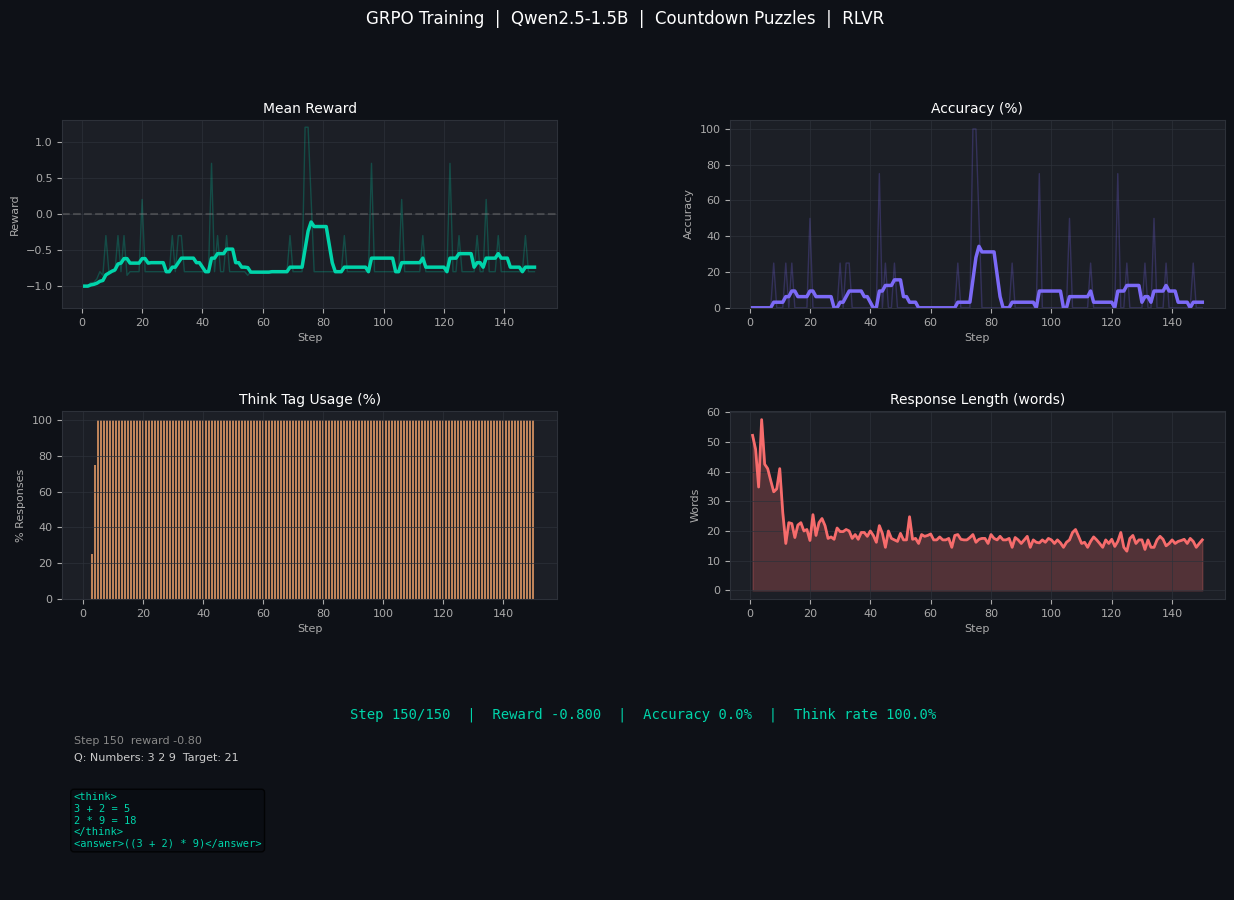

Step  150/150 | Reward -0.800 | Acc 0.0% | Think 100.0%

=== FINAL STATS ===
Steps:       150
Reward:      -0.800
Accuracy:    0.0%
Think rate:  100.0%
Reward trend: -0.835 -> -0.750 (+0.085)

Screenshot the activation heatmap and this dashboard for your portfolio!


In [9]:
# Cell 9: Before vs after on the same puzzle
print('=== AFTER GRPO ===')
with torch.no_grad():
    out = model.generate(**test_input, max_new_tokens=180, do_sample=True,
                         temperature=0.8, pad_token_id=tokenizer.pad_token_id)
after_response = tokenizer.decode(out[0][test_input['input_ids'].shape[1]:], skip_special_tokens=True)
after_reward   = compute_reward(after_response, test_puzzle['numbers'], test_puzzle['target'])

print(f'Problem: {test_puzzle["problem"]}')
print(f'Known solution: {test_puzzle["solution"]}')
print()
print(f'--- BEFORE GRPO (reward {baseline_reward:+.2f}) ---')
print(baseline_response)
print()
print(f'--- AFTER GRPO (reward {after_reward:+.2f}) ---')
print(after_response)

# Final summary chart
plot_dashboard()
print('\n=== FINAL STATS ===')
print(f'Steps:       {log["steps"][-1]}')
print(f'Reward:      {log["rewards"][-1]:+.3f}')
print(f'Accuracy:    {log["accuracies"][-1]:.1%}')
print(f'Think rate:  {log["think_rates"][-1]:.1%}')
if len(log['rewards']) >= 20:
    early = sum(log['rewards'][:10])/10
    late  = sum(log['rewards'][-10:])/10
    print(f'Reward trend: {early:+.3f} -> {late:+.3f} ({late-early:+.3f})')
print('\nScreenshot the activation heatmap and this dashboard for your portfolio!')